# 5.1 — Correlation Analysis: Latent Dimensions × Clinical Factors 

## What this notebook does
1. Loads the clean train/val files from notebook 5.0  
2. Filters to active latent dimensions (KL/variance threshold)  
3. Tests correlation between each active dimension and 12 clinical/demographic factors  
4. Applies Bonferroni correction for multiple comparisons  
5. Validates significant findings on the patient-stratified held-out set  
6. Runs ANCOVA to separate scanner effects from biological signal  
7. Produces the correlation heatmap and ANCOVA scatter plot  



## 1. Import and Configuration

In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
warnings.filterwarnings('ignore')


BETA_SUFFIX = 'beta_3e5'
# File paths
TRAIN_FILE = f'../../data/processed/clinical_merged/train_{BETA_SUFFIX}.csv'
VAL_FILE = f'../../data/processed/clinical_merged/val_{BETA_SUFFIX}.csv'
# SCALER_PATH = '../../results/models/scaler_sbr.pkl'
# PCA_PATH = '../../results/models/pca_sbr.pkl'
KL_FILE = '../../data/baseline/kl_divergence_3.00e-05.csv'


OUTPUT_DIR = '../../results/correlation'
FIGURES_DIR = '../../results/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


# Parameters
PATIENT_COL        = 'PATNO'
LABEL_COL          = 'label'
LATENT_COLS        = [f'latent_{i}' for i in range(256)]
VARIANCE_THRESHOLD = 0.24    # dims with std below this = collapsed
ALPHA              = 0.05   # base significance level
VAL_ALPHA          = 0.1    # lenient threshold for validation confirmation


# Clinical Factors
 # Continuous -> Pearson r^2
CONTINUOUS_FACTORS  = ['AGE_AT_VISIT', 'UPDRS3_TOTAL', 'MOCA_TOTAL', 'NP3_PC2',
    'BradyRig_Total',
    'Tremor_Total',
    'AI_BradyRig_Diff',
    'AI_Tremor_Diff',
    'AI_BradyRig_Norm',
    'AI_Tremor_Norm']

# Categorical
CATEGORICAL_FACTORS = ['Sex', 'HANDED', 'HOEHN_YAHR']

ALL_FACTORS = CONTINUOUS_FACTORS + CATEGORICAL_FACTORS

print("Configuration loaded.")
print(f"  Continuous factors:  {len(CONTINUOUS_FACTORS)}")
print(f"  Categorical factors: {len(CATEGORICAL_FACTORS)}")
print(f"  Total factors:       {len(ALL_FACTORS)}")

Configuration loaded.
  Continuous factors:  10
  Categorical factors: 3
  Total factors:       13


## 2. Load Data

In [3]:
df_train = pd.read_csv(TRAIN_FILE)
df_val   = pd.read_csv(VAL_FILE)

# Load pre-fitted SBR PCA objects
# with open(SCALER_PATH, 'rb') as f: scaler_sbr = pickle.load(f)
# with open(PCA_PATH,    'rb') as f: pca_sbr    = pickle.load(f)

print("Data loaded")
print(f"Train: {df_train.shape}, {df_train[PATIENT_COL].nunique()} patients")
print(f"Val:   {df_val.shape},   {df_val[PATIENT_COL].nunique()} patients")

print(f"\nLabel distribution (train):")
print(df_train[LABEL_COL].value_counts().to_string())

print(f"\nFactor availability in train:")
for f in ALL_FACTORS:
    if f in df_train.columns:
        pct = df_train[f].notna().mean() * 100
        print(f"  {f:<25} {pct:.1f}%")
    else:
        print(f"  {f:<25} MISSING")

Data loaded
Train: (3085, 281), 1678 patients
Val:   (784, 281),   420 patients

Label distribution (train):
label
PD         2666
Control     313
SWEDD       106

Factor availability in train:
  AGE_AT_VISIT              99.8%
  UPDRS3_TOTAL              81.0%
  MOCA_TOTAL                93.5%
  NP3_PC2                   81.0%
  BradyRig_Total            81.0%
  Tremor_Total              81.0%
  AI_BradyRig_Diff          81.0%
  AI_Tremor_Diff            81.0%
  AI_BradyRig_Norm          81.0%
  AI_Tremor_Norm            81.0%
  Sex                       99.8%
  HANDED                    99.9%
  HOEHN_YAHR                81.0%


In [4]:
# LOAD-SBR-TRACK

df_sbr_scores = pd.read_csv('../../results/models/sbr_xing_pca_scores.csv')

# Keep only join key and PC scores
df_sbr_scores = df_sbr_scores[
    ['PATNO', 'EVENT_ID', 'SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']
].drop_duplicates(subset=['PATNO', 'EVENT_ID'], keep='first')

# Merge onto train and val
df_train_sbr = df_train.merge(df_sbr_scores, on=['PATNO', 'EVENT_ID'], how='left').rename(columns={'SBR_XING_PC1_x': 'SBR_XING_PC1', 'SBR_XING_PC2_x': 'SBR_XING_PC2', 'SBR_XING_PC3_x': 'SBR_XING_PC3'})
df_val_sbr   = df_val.merge(df_sbr_scores,   on=['PATNO', 'EVENT_ID'], how='left').rename(columns={'SBR_XING_PC1_x': 'SBR_XING_PC1', 'SBR_XING_PC2_x': 'SBR_XING_PC2', 'SBR_XING_PC3_x': 'SBR_XING_PC3'})

n_train = df_train_sbr['SBR_XING_PC1'].notna().sum()
n_val   = df_val_sbr['SBR_XING_PC1'].notna().sum()

print(f"SBR track coverage:")
print(f"  Train: {n_train} / {len(df_train_sbr)} ({n_train/len(df_train_sbr)*100:.1f}%)")
print(f"  Val:   {n_val} / {len(df_val_sbr)} ({n_val/len(df_val_sbr)*100:.1f}%)")

SBR track coverage:
  Train: 2135 / 3085 (69.2%)
  Val:   567 / 784 (72.3%)


## 3. Filter to Activate Latent Dimension
Collapsed dimensions (std < threshold) carry no information and would inflate 
the multiple comparison burden. They are excluded before any statistical testing

In [5]:
df_kl       = pd.read_csv(KL_FILE)
active_dims = df_kl[df_kl['mean_kl'] > 0.05]['dimension'].tolist()
collapsed_dims = df_kl[df_kl['mean_kl'] <= 0.05]['dimension'].tolist()

print(f"Total dimensions:  {len(df_kl)}")
print(f"Active dimensions: {len(active_dims)}")
print(f"Collapsed:         {len(collapsed_dims)}")
print(f"Collapse rate:     {len(collapsed_dims)/len(df_kl)*100:.1f}%")

Total dimensions:  256
Active dimensions: 108
Collapsed:         148
Collapse rate:     57.8%


## 4. Bonferroni Correction

In [6]:
n_tests    = len(active_dims)
alpha_bonf = ALPHA / n_tests

print(f"Active dimensions (= number of tests per factor): {n_tests}")
print(f"Base alpha:       {ALPHA}")
print(f"Bonferroni alpha: {ALPHA}/{n_tests} = {alpha_bonf:.6f}")
# print(f"\nInterpretation: a dimension must achieve p < {alpha_bonf:.6f}")
# print(f"to be considered significant after correction.")

Active dimensions (= number of tests per factor): 108
Base alpha:       0.05
Bonferroni alpha: 0.05/108 = 0.000463


## 5. Correlation Tests — Training Set
For each active dimension × each factor:  
- **Continuous factors** → Pearson r (effect size = r^2)  
- **Categorical factors** → one-way ANOVA (effect size = η^2)


In [7]:
def pearson_test(series_a, series_b):
    valid = pd.concat([series_a, series_b], axis=1).dropna()
    if len(valid) < 10:
        return np.nan, np.nan, np.nan
    r, p = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
    return r, r**2, p

# One-way ANOVA
def eta_squared_test(df, dim_col, group_col):
    groups = [df[df[group_col] == g][dim_col].dropna().values
              for g in df[group_col].dropna().unique()]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        return np.nan, np.nan
    _, p       = stats.f_oneway(*groups)
    grand_mean = df[dim_col].mean()
    ss_total   = ((df[dim_col] - grand_mean)**2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    eta2       = ss_between / ss_total if ss_total > 0 else 0
    return eta2, p

print("Running correlation tests...")
train_results = []

for dim in active_dims:
    row = {'dimension': dim}

    for factor in CONTINUOUS_FACTORS:
        if factor not in df_train.columns:
            row[f'{factor}_r']   = np.nan
            row[f'{factor}_r2']  = np.nan
            row[f'{factor}_p']   = np.nan
            row[f'{factor}_sig'] = False
            continue
        r, r2, p = pearson_test(df_train[dim], df_train[factor])
        row[f'{factor}_r']   = round(r,  4) if not np.isnan(r) else np.nan
        row[f'{factor}_r2']  = round(r2, 4) if not np.isnan(r2) else np.nan
        row[f'{factor}_p']   = round(p,  6) if not np.isnan(p) else np.nan
        row[f'{factor}_sig'] = bool(p < alpha_bonf) if not np.isnan(p) else False

    for factor in CATEGORICAL_FACTORS:
        if factor not in df_train.columns:
            row[f'{factor}_eta2'] = np.nan
            row[f'{factor}_p']    = np.nan
            row[f'{factor}_sig']  = False
            continue
        eta2, p = eta_squared_test(df_train, dim, factor)
        row[f'{factor}_eta2'] = round(eta2, 4) if not np.isnan(eta2) else np.nan
        row[f'{factor}_p']    = round(p,    6) if not np.isnan(p)    else np.nan
        row[f'{factor}_sig']  = bool(p < alpha_bonf) if not np.isnan(p) else False

    train_results.append(row)

df_results = pd.DataFrame(train_results)

# Summary of significant findings
print("\n Significant dimensions per factor (Bonferroni corrected)")
for factor in CONTINUOUS_FACTORS:
    col = f'{factor}_sig'
    if col in df_results.columns:
        n_sig = df_results[col].sum()
        print(f"  {factor:<25} {n_sig:>3} / {len(active_dims)} dims significant")
for factor in CATEGORICAL_FACTORS:
    col = f'{factor}_sig'
    if col in df_results.columns:
        n_sig = df_results[col].sum()
        print(f"  {factor:<25} {n_sig:>3} / {len(active_dims)} dims significant")

df_results.to_csv(f'{OUTPUT_DIR}/correlation_train_{BETA_SUFFIX}.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/correlation_train_{BETA_SUFFIX}.csv")

Running correlation tests...

 Significant dimensions per factor (Bonferroni corrected)
  AGE_AT_VISIT               58 / 108 dims significant
  UPDRS3_TOTAL               46 / 108 dims significant
  MOCA_TOTAL                 36 / 108 dims significant
  NP3_PC2                    46 / 108 dims significant
  BradyRig_Total             43 / 108 dims significant
  Tremor_Total               21 / 108 dims significant
  AI_BradyRig_Diff           49 / 108 dims significant
  AI_Tremor_Diff             39 / 108 dims significant
  AI_BradyRig_Norm           48 / 108 dims significant
  AI_Tremor_Norm             43 / 108 dims significant
  Sex                        58 / 108 dims significant
  HANDED                      4 / 108 dims significant
  HOEHN_YAHR                 60 / 108 dims significant

Saved: ../../results/correlation/correlation_train_beta_3e5.csv


In [8]:
# CHECK-MISSING-FACTORS
missing = []
for f in ALL_FACTORS:
    if f not in df_train.columns:
        missing.append(f)
    else:
        coverage = df_train[f].notna().mean() * 100
        print(f"  {f:<25} coverage: {coverage:.1f}%")

print(f"\nMissing columns: {missing}")
print(CONTINUOUS_FACTORS)
print(CATEGORICAL_FACTORS)
print([c for c in df_train.columns if 'NP3' in c or 'HANDED' in c])

  AGE_AT_VISIT              coverage: 99.8%
  UPDRS3_TOTAL              coverage: 81.0%
  MOCA_TOTAL                coverage: 93.5%
  NP3_PC2                   coverage: 81.0%
  BradyRig_Total            coverage: 81.0%
  Tremor_Total              coverage: 81.0%
  AI_BradyRig_Diff          coverage: 81.0%
  AI_Tremor_Diff            coverage: 81.0%
  AI_BradyRig_Norm          coverage: 81.0%
  AI_Tremor_Norm            coverage: 81.0%
  Sex                       coverage: 99.8%
  HANDED                    coverage: 99.9%
  HOEHN_YAHR                coverage: 81.0%

Missing columns: []
['AGE_AT_VISIT', 'UPDRS3_TOTAL', 'MOCA_TOTAL', 'NP3_PC2', 'BradyRig_Total', 'Tremor_Total', 'AI_BradyRig_Diff', 'AI_Tremor_Diff', 'AI_BradyRig_Norm', 'AI_Tremor_Norm']
['Sex', 'HANDED', 'HOEHN_YAHR']
['HANDED', 'NP3_PC1', 'NP3_PC2', 'NP3_PC3']


In [9]:
# SBR-CORRELATION

SBR_FACTORS = ['SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']

print("Running SBR correlation tests...")
sbr_results = []

for dim in active_dims:
    row = {'dimension': dim}
    for factor in SBR_FACTORS:
        r, r2, p = pearson_test(df_train_sbr[dim], df_train_sbr[factor])
        row[f'{factor}_r']   = round(r,  4) if not np.isnan(r) else np.nan
        row[f'{factor}_r2']  = round(r2, 4) if not np.isnan(r2) else np.nan
        row[f'{factor}_p']   = round(p,  6) if not np.isnan(p) else np.nan
        row[f'{factor}_sig'] = bool(p < alpha_bonf) if not np.isnan(p) else False
    sbr_results.append(row)

df_sbr_results = pd.DataFrame(sbr_results)

print("\n=== SBR significant dimensions (Bonferroni corrected) ===")
for factor in SBR_FACTORS:
    n_sig = df_sbr_results[f'{factor}_sig'].sum()
    print(f"  {factor:<20} {n_sig:>3} / {len(active_dims)} dims significant")

df_sbr_results.to_csv(f'{OUTPUT_DIR}/correlation_sbr_train_{BETA_SUFFIX}.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/correlation_sbr_train_{BETA_SUFFIX}.csv")

Running SBR correlation tests...

=== SBR significant dimensions (Bonferroni corrected) ===
  SBR_XING_PC1          52 / 108 dims significant
  SBR_XING_PC2          57 / 108 dims significant
  SBR_XING_PC3          56 / 108 dims significant

Saved: ../../results/correlation/correlation_sbr_train_beta_3e5.csv


## 6. Validate on Held-Out Set
A result is **validated** if:  
1. It survived Bonferroni correction in training  
2. p < 0.1 in the validation set  
3. Direction (sign) of the correlation is the same in both splits


In [10]:
val_results = []

for _, train_row in df_results.iterrows():
    dim   = train_row['dimension']
    v_row = {'dimension': dim}
   
    for factor in CONTINUOUS_FACTORS:
        # print(f'{factor}_sig ',train_row.get(f'{factor}_sig'))
        # print(train_row)
        # print("-"*40)
        if not train_row.get(f'{factor}_sig', False):
            v_row[f'{factor}_validated'] = False
            continue
        if factor not in df_val.columns:
            v_row[f'{factor}_validated'] = False
            continue
        r_val, _, p_val = pearson_test(df_val[dim], df_val[factor])
        if np.isnan(r_val):
            v_row[f'{factor}_validated'] = False
            continue
        train_r   = train_row.get(f'{factor}_r', 0) or 0
        same_sign = (train_r * r_val) > 0
        v_row[f'{factor}_validated'] = bool(same_sign and p_val < VAL_ALPHA)    

    for factor in CATEGORICAL_FACTORS:
        if not train_row.get(f'{factor}_sig', False):
            v_row[f'{factor}_validated'] = False
            continue
        if factor not in df_val.columns:
            v_row[f'{factor}_validated'] = False
            continue
        groups_val = [df_val[df_val[factor] == g][dim].dropna().values
                      for g in df_val[factor].dropna().unique()
                      if len(df_val[df_val[factor] == g]) >= 3]
        if len(groups_val) < 2:
            v_row[f'{factor}_validated'] = False
            continue
        _, p_val = stats.f_oneway(*groups_val)
        v_row[f'{factor}_validated'] = bool(p_val < VAL_ALPHA)

    val_results.append(v_row)

df_validated = pd.DataFrame(val_results)

print("Validated dimensions per factor")
for factor in ALL_FACTORS:
    col = f'{factor}_validated'
    if col in df_validated.columns:
        n_val = df_validated[col].sum()
        n_sig = df_results[f'{factor}_sig'].sum()
        print(f"  {factor:<25} {n_val:>3} / {n_sig} significant dims validated")

df_validated.to_csv(f'{OUTPUT_DIR}/correlation_val_{BETA_SUFFIX}.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/correlation_val_{BETA_SUFFIX}.csv")

Validated dimensions per factor
  AGE_AT_VISIT               49 / 58 significant dims validated
  UPDRS3_TOTAL               37 / 46 significant dims validated
  MOCA_TOTAL                 16 / 36 significant dims validated
  NP3_PC2                    39 / 46 significant dims validated
  BradyRig_Total             34 / 43 significant dims validated
  Tremor_Total               15 / 21 significant dims validated
  AI_BradyRig_Diff           39 / 49 significant dims validated
  AI_Tremor_Diff             32 / 39 significant dims validated
  AI_BradyRig_Norm           39 / 48 significant dims validated
  AI_Tremor_Norm             34 / 43 significant dims validated
  Sex                        46 / 58 significant dims validated
  HANDED                      1 / 4 significant dims validated
  HOEHN_YAHR                 54 / 60 significant dims validated

Saved: ../../results/correlation/correlation_val_beta_3e5.csv


In [11]:
 # SBR-VALIDATION

sbr_val_results = []

for _, train_row in df_sbr_results.iterrows():
    dim   = train_row['dimension']
    v_row = {'dimension': dim}

    for factor in SBR_FACTORS:
        if not train_row.get(f'{factor}_sig', False):
            v_row[f'{factor}_validated'] = False
            continue
        r_val, _, p_val = pearson_test(df_val_sbr[dim], df_val_sbr[factor])
        if np.isnan(r_val):
            v_row[f'{factor}_validated'] = False
            continue
        train_r   = train_row.get(f'{factor}_r', 0) or 0
        same_sign = (train_r * r_val) > 0
        v_row[f'{factor}_validated'] = bool(same_sign and p_val < VAL_ALPHA)

    sbr_val_results.append(v_row)

df_sbr_validated = pd.DataFrame(sbr_val_results)

print("=== SBR validated dimensions ===")
for factor in SBR_FACTORS:
    col   = f'{factor}_validated'
    n_val = df_sbr_validated[col].sum()
    n_sig = df_sbr_results[f'{factor}_sig'].sum()
    print(f"  {factor:<20} {n_val:>3} / {n_sig} significant dims validated")

df_sbr_validated.to_csv(f'{OUTPUT_DIR}/correlation_sbr_val_{BETA_SUFFIX}.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/correlation_sbr_val_{BETA_SUFFIX}.csv")

=== SBR validated dimensions ===
  SBR_XING_PC1          33 / 52 significant dims validated
  SBR_XING_PC2          43 / 57 significant dims validated
  SBR_XING_PC3          49 / 56 significant dims validated

Saved: ../../results/correlation/correlation_sbr_val_beta_3e5.csv


## 7. ANCOVA — Disentangle Scanner from Biological Signal
Model: `latent_dim ~ SBR_PC1 + SBR_PC2 + SBR_PC3 + AGE_AT_VISIT + SEX`  

Partial η^2 for each effect tells us how much variance it explains  
**independently** of all other effects in the model.  

Each dimension is classified as:  
- **Biological** — significant for at least one clinical factor, not scanner  
- **Mixed** — significant for both  
- **Neither** — no significant effect  


In [12]:
# ANCOVA

# Build ANCOVA covariate list from available columns
ancova_covariates = []
for col in ['AGE_AT_VISIT', 'Sex']:
    if col in df_train.columns and df_train[col].notna().sum() > 100:
        ancova_covariates.append(col)

print(f"ANCOVA covariates: {ancova_covariates}")
print(f"Running ANCOVA for {len(active_dims)} active dimensions...\n")

ancova_results = []

for dim in active_dims:
    cols_needed = [dim] + ancova_covariates
    data = df_train[cols_needed].dropna()

    if len(data) < 50 or len(ancova_covariates) == 0:
        ancova_results.append({
            'dimension': dim,
            'peta2_scanner': np.nan, 'peta2_biological': np.nan,
            'p_scanner': np.nan, 'p_biological': np.nan,
            'category': 'Insufficient data'
        })
        continue

    # Build formula — no scanner term since Manufacturer not available
    cont_terms = ' + '.join(ancova_covariates)
    formula    = f"{dim} ~ {cont_terms}"

    try:
        model  = ols(formula, data=data).fit()
        tbl    = sm.stats.anova_lm(model, typ=2)

        # Biological signal = combined effect of all covariates
        ss_bio = sum(tbl.loc[c, 'sum_sq'] for c in ancova_covariates if c in tbl.index)
        ss_res = tbl.loc['Residual', 'sum_sq']
        p_bio  = min(tbl.loc[c, 'PR(>F)'] for c in ancova_covariates if c in tbl.index)

        peta2_bio = ss_bio / (ss_bio + ss_res)

        sig_bio = p_bio < ALPHA

        if sig_bio:
            cat = 'Biological'
        else:
            cat = 'Neither'

        ancova_results.append({
            'dimension':        dim,
            'peta2_scanner':    np.nan,
            'peta2_biological': round(peta2_bio, 4),
            'p_scanner':        np.nan,
            'p_biological':     round(p_bio, 6),
            'category':         cat,
        })
    except Exception as e:
        ancova_results.append({
            'dimension': dim, 'peta2_scanner': np.nan,
            'peta2_biological': np.nan, 'p_scanner': np.nan,
            'p_biological': np.nan, 'category': 'Error'
        })

df_ancova = pd.DataFrame(ancova_results)


ANCOVA covariates: ['AGE_AT_VISIT', 'Sex']
Running ANCOVA for 108 active dimensions...



In [13]:
# Apply effect size threshold
EFFECT_THRESHOLD = 0.05

def reclassify(row):
    sig_bio     = row['peta2_biological'] > EFFECT_THRESHOLD
    sig_scanner = row['peta2_scanner']    > EFFECT_THRESHOLD
    if   sig_bio and not sig_scanner: return 'Biological'
    elif sig_scanner and not sig_bio: return 'Scanner-only'
    elif sig_bio and sig_scanner:     return 'Mixed'
    else:                             return 'Neither'

df_ancova['category'] = df_ancova.apply(reclassify, axis=1)

print("=== Corrected ANCOVA categories ===")
print(df_ancova['category'].value_counts().to_string())

safe_dims    = df_ancova[df_ancova['category'] == 'Biological']['dimension'].tolist()
scanner_dims = df_ancova[df_ancova['category'] == 'Scanner-only']['dimension'].tolist()
mixed_dims   = df_ancova[df_ancova['category'] == 'Mixed']['dimension'].tolist()

print(f"\nBiological dims: {safe_dims}")
print(f"Scanner-only:    {scanner_dims}")
print(f"Mixed:           {mixed_dims}")

# Save corrected results
df_ancova.to_csv(f'../../results/correlation/ancova_results_{BETA_SUFFIX}.csv', index=False)
print(f"\nSaved corrected: ancova_results_{BETA_SUFFIX}.csv")

=== Corrected ANCOVA categories ===
category
Neither       97
Biological    11

Biological dims: ['latent_3', 'latent_15', 'latent_51', 'latent_66', 'latent_83', 'latent_106', 'latent_114', 'latent_116', 'latent_141', 'latent_222', 'latent_235']
Scanner-only:    []
Mixed:           []

Saved corrected: ancova_results_beta_3e5.csv


## 8. Correlation Heatmap

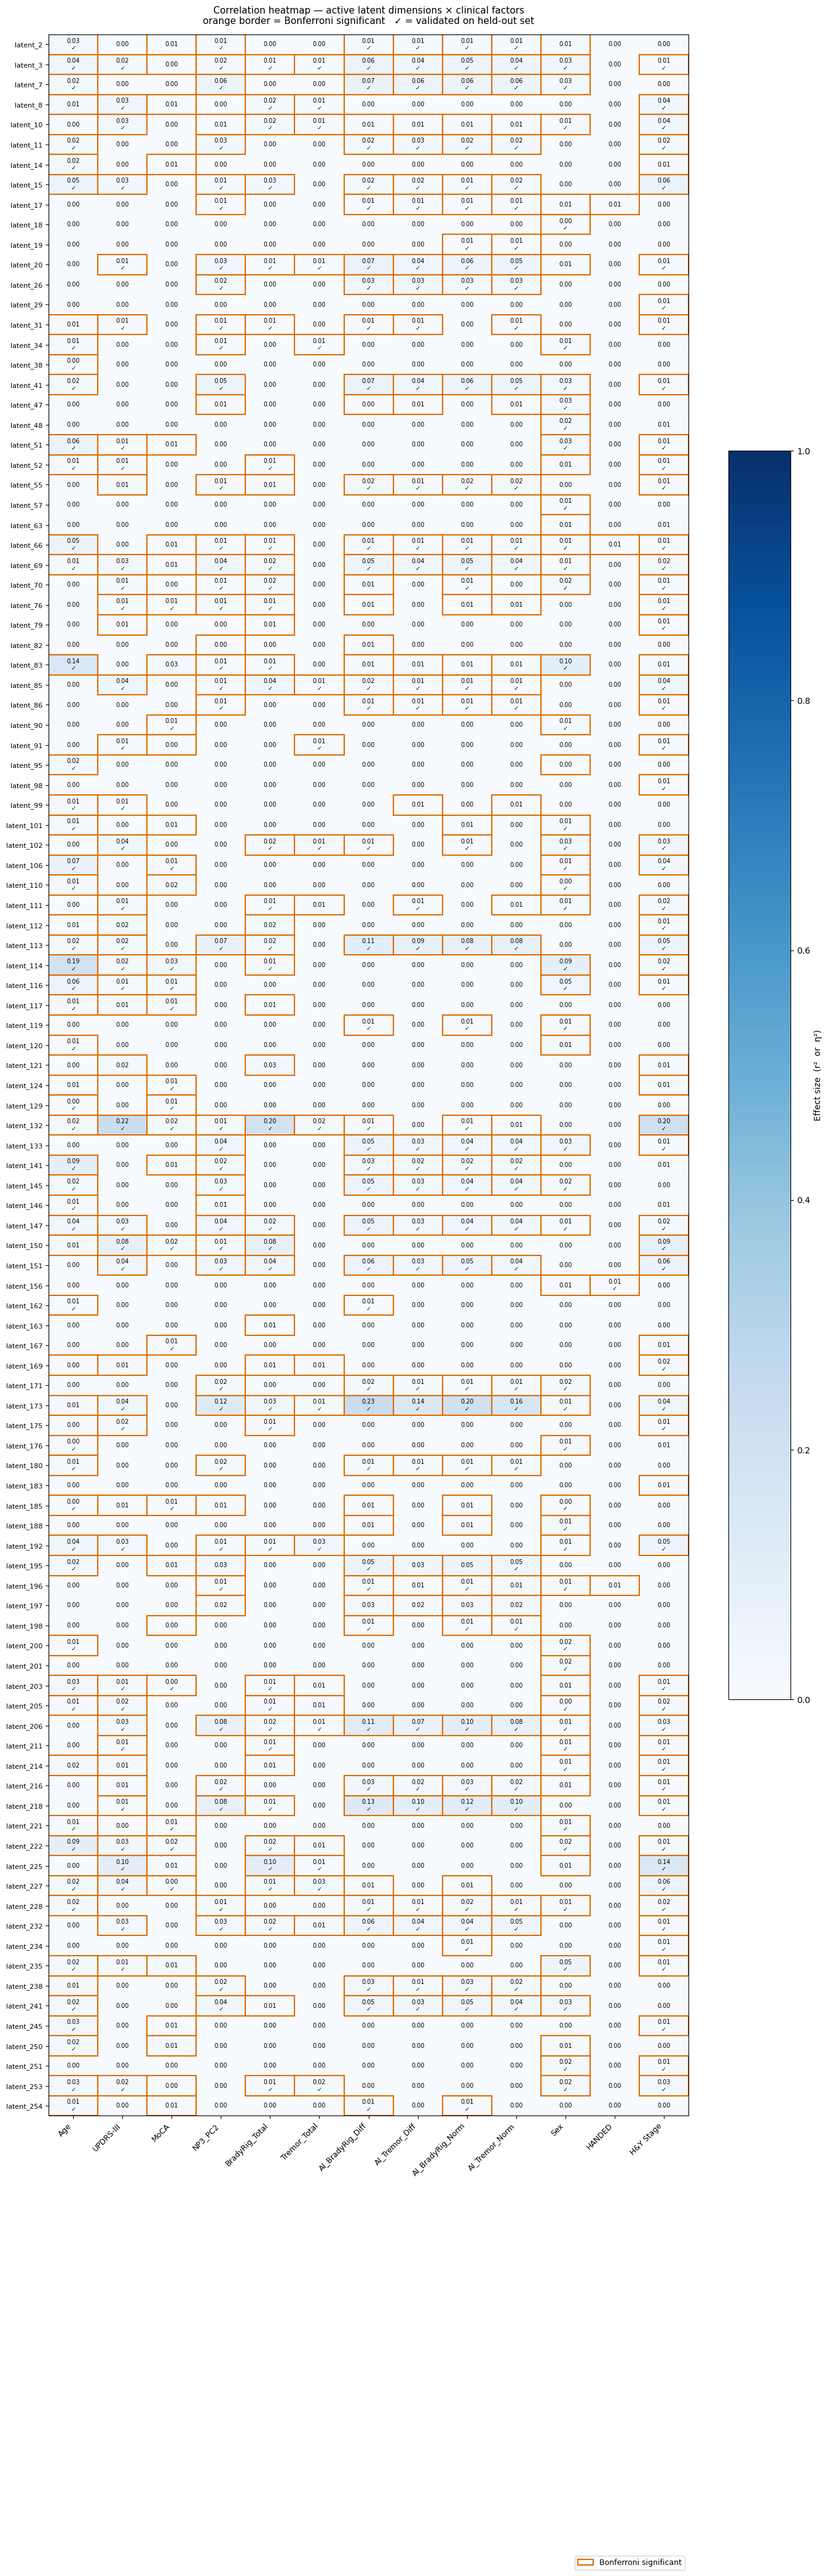

Saved: ../../results/figures/correlation_heatmap_beta_3e5.png

Showing 104 significant dimensions out of 108 active


In [14]:
# Only show dimensions significant for at least one factor
sig_any = df_results[[f'{f}_sig' for f in ALL_FACTORS
                       if f'{f}_sig' in df_results.columns]].any(axis=1)
df_sig  = df_results[sig_any].copy()

if len(df_sig) == 0:
    print("No significant dimensions found — check Bonferroni threshold.")
else:
    # Build effect size matrix
    factor_labels = {
    'AGE_AT_VISIT':  'Age',
    'UPDRS3_TOTAL':  'UPDRS-III',
    'MOCA_TOTAL':    'MoCA',
    'Sex':           'Sex',
    'HOEHN_YAHR':    'H&Y Stage',
    }

    dims_to_show = df_sig['dimension'].tolist()
    factors_available = [f for f in ALL_FACTORS
                         if f'{f}_sig' in df_results.columns]

    effect_matrix = np.zeros((len(dims_to_show), len(factors_available)))
    sig_matrix    = np.zeros((len(dims_to_show), len(factors_available)), dtype=bool)
    val_matrix    = np.zeros((len(dims_to_show), len(factors_available)), dtype=bool)

    for i, dim in enumerate(dims_to_show):
        t_row = df_results[df_results['dimension'] == dim].iloc[0]
        v_row = df_validated[df_validated['dimension'] == dim].iloc[0]
        for j, factor in enumerate(factors_available):
            if factor in CONTINUOUS_FACTORS:
                effect_matrix[i, j] = t_row.get(f'{factor}_r2', 0) or 0
            else:
                effect_matrix[i, j] = t_row.get(f'{factor}_eta2', 0) or 0
            sig_matrix[i, j] = bool(t_row.get(f'{factor}_sig', False))
            val_matrix[i, j] = bool(v_row.get(f'{factor}_validated', False))

    fig, ax = plt.subplots(figsize=(14, max(6, len(dims_to_show) * 0.4)))
    im = ax.imshow(effect_matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')

    xlabels = [factor_labels.get(f, f) for f in factors_available]
    ax.set_xticks(range(len(factors_available)))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(dims_to_show)))
    ax.set_yticklabels(dims_to_show, fontsize=8)
    ax.set_title(
        'Correlation heatmap — active latent dimensions × clinical factors\n'
        'orange border = Bonferroni significant   ✓ = validated on held-out set',
        fontsize=11, pad=12
    )

    for i in range(len(dims_to_show)):
        for j in range(len(factors_available)):
            v = effect_matrix[i, j]
            if sig_matrix[i, j]:
                ax.add_patch(plt.Rectangle(
                    [j-0.5, i-0.5], 1, 1,
                    fill=False, edgecolor='#e06c00', linewidth=1.5
                ))
            label = f'{v:.2f}' + ('\n✓' if val_matrix[i, j] else '')
            ax.text(j, i, label, ha='center', va='center',
                    fontsize=7, color='white' if v > 0.5 else 'black')

    plt.colorbar(im, ax=ax, label='Effect size  (r²  or  η²)', shrink=0.6)
    ax.legend(
        handles=[mpatches.Patch(fill=False, edgecolor='#e06c00',
                 linewidth=1.5, label='Bonferroni significant')],
        loc='lower right', bbox_to_anchor=(1.0, -0.22), fontsize=9
    )
    plt.tight_layout()
    path = f'{FIGURES_DIR}/correlation_heatmap_{BETA_SUFFIX}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")
    print(f"\nShowing {len(dims_to_show)} significant dimensions out of {len(active_dims)} active")

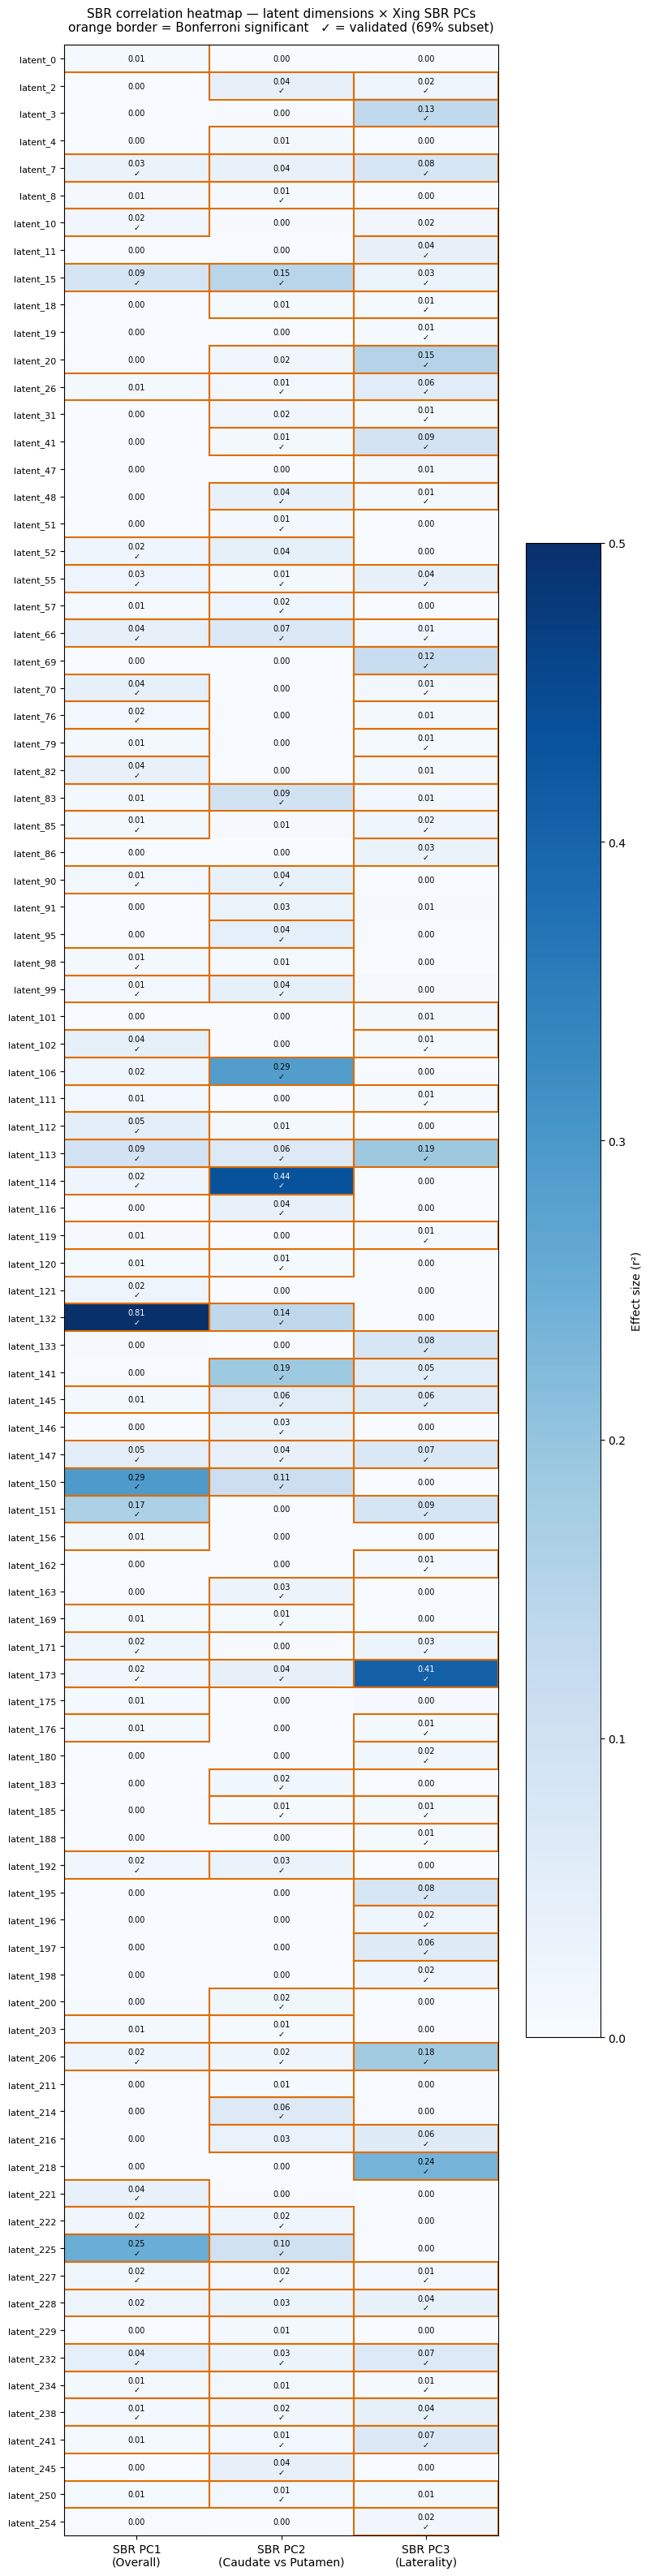

Saved: ../../results/figures/correlation_heatmap_sbr_beta_3e5.png
Showing 91 significant dimensions out of 108 active


In [15]:
# [SBR-HEATMAP]

sig_any_sbr = df_sbr_results[[f'{f}_sig' for f in SBR_FACTORS]].any(axis=1)
df_sbr_sig  = df_sbr_results[sig_any_sbr].copy()

dims_to_show = df_sbr_sig['dimension'].tolist()
effect_matrix = np.zeros((len(dims_to_show), len(SBR_FACTORS)))
sig_matrix    = np.zeros((len(dims_to_show), len(SBR_FACTORS)), dtype=bool)
val_matrix    = np.zeros((len(dims_to_show), len(SBR_FACTORS)), dtype=bool)

for i, dim in enumerate(dims_to_show):
    t_row = df_sbr_results[df_sbr_results['dimension'] == dim].iloc[0]
    v_row = df_sbr_validated[df_sbr_validated['dimension'] == dim].iloc[0]
    for j, factor in enumerate(SBR_FACTORS):
        effect_matrix[i, j] = t_row.get(f'{factor}_r2', 0) or 0
        sig_matrix[i, j]    = bool(t_row.get(f'{factor}_sig', False))
        val_matrix[i, j]    = bool(v_row.get(f'{factor}_validated', False))

fig, ax = plt.subplots(figsize=(8, max(6, len(dims_to_show) * 0.35)))
im = ax.imshow(effect_matrix, cmap='Blues', vmin=0, vmax=0.5, aspect='auto')

ax.set_xticks(range(len(SBR_FACTORS)))
ax.set_xticklabels(['SBR PC1\n(Overall)', 'SBR PC2\n(Caudate vs Putamen)', 'SBR PC3\n(Laterality)'],
                   fontsize=10)
ax.set_yticks(range(len(dims_to_show)))
ax.set_yticklabels(dims_to_show, fontsize=8)
ax.set_title('SBR correlation heatmap — latent dimensions × Xing SBR PCs\n'
             'orange border = Bonferroni significant   ✓ = validated (69% subset)',
             fontsize=11, pad=12)

for i in range(len(dims_to_show)):
    for j in range(len(SBR_FACTORS)):
        v = effect_matrix[i, j]
        if sig_matrix[i, j]:
            ax.add_patch(plt.Rectangle([j-0.5, i-0.5], 1, 1,
                         fill=False, edgecolor='#e06c00', linewidth=1.5))
        label = f'{v:.2f}' + ('\n✓' if val_matrix[i, j] else '')
        ax.text(j, i, label, ha='center', va='center',
                fontsize=7, color='white' if v > 0.3 else 'black')

plt.colorbar(im, ax=ax, label='Effect size (r²)', shrink=0.6)
plt.tight_layout()
path = f'{FIGURES_DIR}/correlation_heatmap_sbr_{BETA_SUFFIX}.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")
print(f"Showing {len(dims_to_show)} significant dimensions out of {len(active_dims)} active")

## 9. ANCOVA Scatter Plot

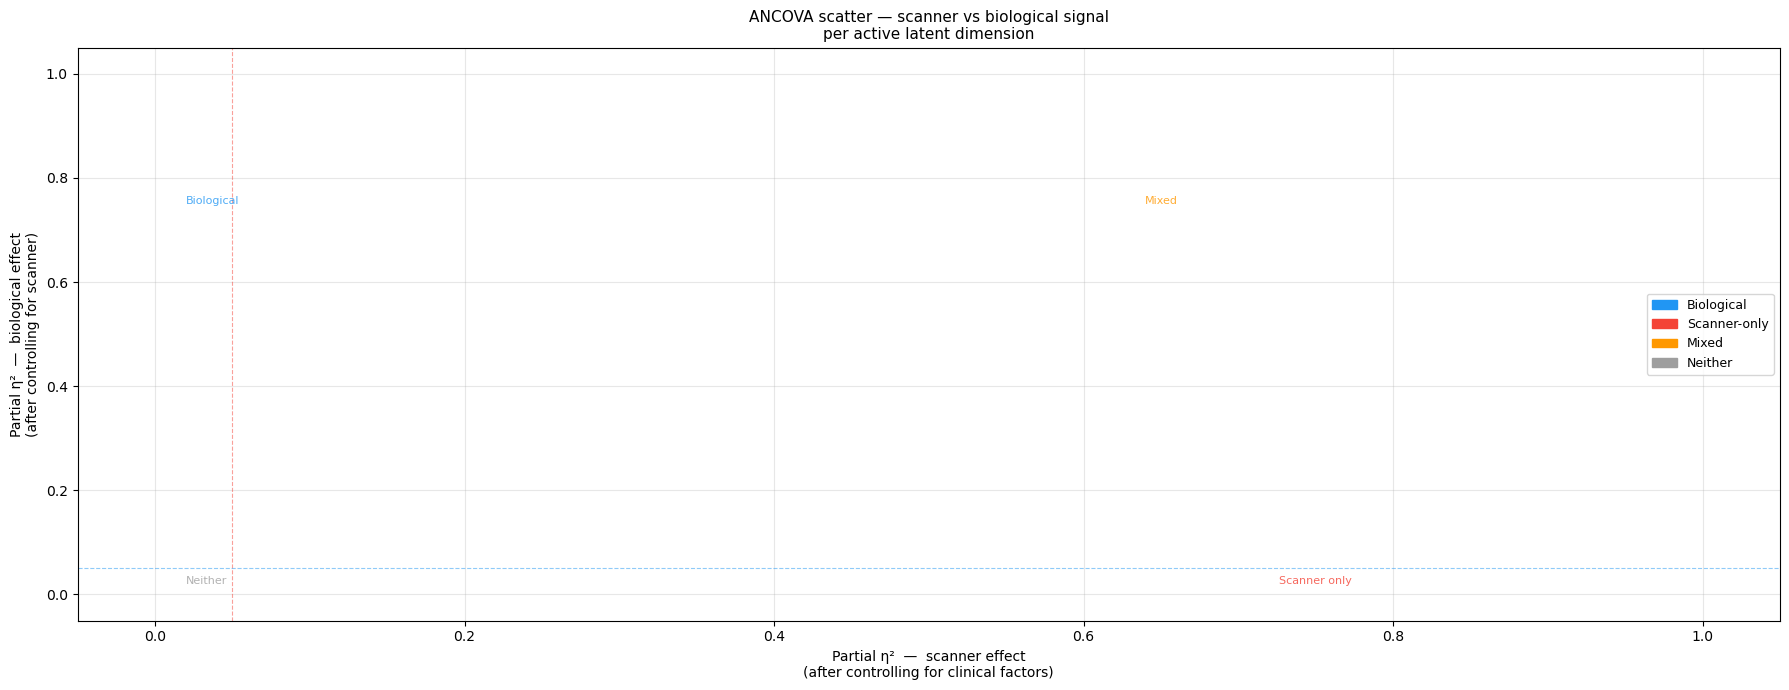

Saved: ../../results/figures/ancova_scatter_beta_3e5.png


In [16]:
df_anc = df_ancova.dropna(subset=['peta2_scanner', 'peta2_biological'])

color_map = {
    'Biological':   '#2196F3',
    'Scanner-only': '#F44336',
    'Mixed':        '#FF9800',
    'Neither':      '#9E9E9E',
}
colors = [color_map.get(c, '#9E9E9E') for c in df_anc['category']]

fig, ax = plt.subplots(figsize=(18, 7))
ax.scatter(df_anc['peta2_scanner'], df_anc['peta2_biological'],
           c=colors, s=80, edgecolors='white', linewidths=0.6, zorder=3)

for _, row in df_anc.iterrows():
    if row['peta2_scanner'] > 0.05 or row['peta2_biological'] > 0.05:
        ax.annotate(row['dimension'],
                    (row['peta2_scanner'], row['peta2_biological']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.axvline(0.05, color='#F44336', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(0.05, color='#2196F3', linestyle='--', linewidth=0.8, alpha=0.5)

ax.text(0.75, 0.02, 'Scanner only',  ha='center', fontsize=8, color='#F44336', alpha=0.8)
ax.text(0.02, 0.75, 'Biological',    ha='left',   fontsize=8, color='#2196F3', alpha=0.8)
ax.text(0.65, 0.75, 'Mixed',         ha='center', fontsize=8, color='#FF9800', alpha=0.8)
ax.text(0.02, 0.02, 'Neither',       ha='left',   fontsize=8, color='#9E9E9E', alpha=0.8)

ax.set_xlabel('Partial η²  —  scanner effect\n(after controlling for clinical factors)', fontsize=10)
ax.set_ylabel('Partial η²  —  biological effect\n(after controlling for scanner)', fontsize=10)
ax.set_title('ANCOVA scatter — scanner vs biological signal\nper active latent dimension', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(
    handles=[mpatches.Patch(color=v, label=k) for k, v in color_map.items()],
    fontsize=9, loc='center right', bbox_to_anchor=(1.0, 0.5)
)
plt.tight_layout()
path = f'{FIGURES_DIR}/ancova_scatter_{BETA_SUFFIX}.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

In [17]:
EFFECT_THRESHOLD = 0.05  # minimum partial eta2 to call an effect "meaningful"

def reclassify(row):
    sig_bio     = row['peta2_biological'] > EFFECT_THRESHOLD
    sig_scanner = row['peta2_scanner']    > EFFECT_THRESHOLD
    if   sig_bio and not sig_scanner: return 'Biological'
    elif sig_scanner and not sig_bio: return 'Scanner-only'
    elif sig_bio and sig_scanner:     return 'Mixed'
    else:                             return 'Neither'

df_ancova['category'] = df_ancova.apply(reclassify, axis=1)

print(" Corrected ANCOVA categories ")
print(df_ancova['category'].value_counts().to_string())

safe_dims    = df_ancova[df_ancova['category'] == 'Biological']['dimension'].tolist()
scanner_dims = df_ancova[df_ancova['category'] == 'Scanner-only']['dimension'].tolist()
mixed_dims   = df_ancova[df_ancova['category'] == 'Mixed']['dimension'].tolist()

print(f"\nBiological dims: {safe_dims}")
print(f"Scanner-only:    {scanner_dims}")
print(f"Mixed:           {mixed_dims}")

 Corrected ANCOVA categories 
category
Neither       97
Biological    11

Biological dims: ['latent_3', 'latent_15', 'latent_51', 'latent_66', 'latent_83', 'latent_106', 'latent_114', 'latent_116', 'latent_141', 'latent_222', 'latent_235']
Scanner-only:    []
Mixed:           []


## 10. Summary

In [18]:
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nDataset:")
print(f"  Train: {len(df_train)} rows, {df_train[PATIENT_COL].nunique()} patients")
print(f"  Val:   {len(df_val)} rows,   {df_val[PATIENT_COL].nunique()} patients")
print(f"  Patient overlap: 0 ✓")

print(f"\nLatent space:")
print(f"  Active dimensions: {len(active_dims)} / {len(LATENT_COLS)}")
print(f"  Collapse rate:     {len(collapsed_dims)/len(LATENT_COLS)*100:.1f}%")

print(f"\nBonferroni threshold: p < {alpha_bonf:.6f}")

print(f"\nSignificant findings (Bonferroni corrected):")
for factor in ALL_FACTORS:
    col = f'{factor}_sig'
    if col in df_results.columns:
        n_sig = int(df_results[col].sum())
        col_v = f'{factor}_validated'
        n_val = int(df_validated[col_v].sum()) if col_v in df_validated.columns else 0
        if n_sig > 0:
            print(f"  {factor:<25} {n_sig:>3} significant, {n_val:>3} validated")

print(f"\nANCOVA classification:")
print(df_ancova['category'].value_counts().to_string())

print(f"\nOutputs saved to:")
print(f"  {OUTPUT_DIR}/correlation_train_{BETA_SUFFIX}.csv")
print(f"  {OUTPUT_DIR}/correlation_val_{BETA_SUFFIX}.csv")
print(f"  {OUTPUT_DIR}/ancova_results_{BETA_SUFFIX}.csv")
print(f"  {FIGURES_DIR}/correlation_heatmap_{BETA_SUFFIX}.png")
print(f"  {FIGURES_DIR}/ancova_scatter_{BETA_SUFFIX}.png")

ANALYSIS SUMMARY

Dataset:
  Train: 3085 rows, 1678 patients
  Val:   784 rows,   420 patients
  Patient overlap: 0 ✓

Latent space:
  Active dimensions: 108 / 256
  Collapse rate:     57.8%

Bonferroni threshold: p < 0.000463

Significant findings (Bonferroni corrected):
  AGE_AT_VISIT               58 significant,  49 validated
  UPDRS3_TOTAL               46 significant,  37 validated
  MOCA_TOTAL                 36 significant,  16 validated
  NP3_PC2                    46 significant,  39 validated
  BradyRig_Total             43 significant,  34 validated
  Tremor_Total               21 significant,  15 validated
  AI_BradyRig_Diff           49 significant,  39 validated
  AI_Tremor_Diff             39 significant,  32 validated
  AI_BradyRig_Norm           48 significant,  39 validated
  AI_Tremor_Norm             43 significant,  34 validated
  Sex                        58 significant,  46 validated
  HANDED                      4 significant,   1 validated
  HOEHN_YAHR       